# Heart Disease Prediction

Der Datensatz für diese Übung kommt von [https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)

Laden Sie den Datensatz. Es gibt 5 numerische Feature die potentiell normalverteilt sein könnten: "Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"

Plotten Sie für all diese ein Histogram.

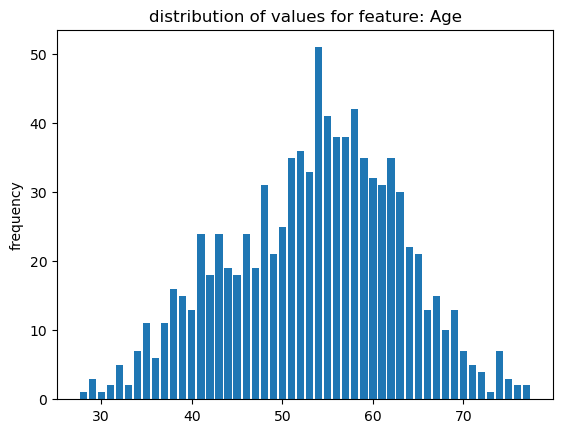

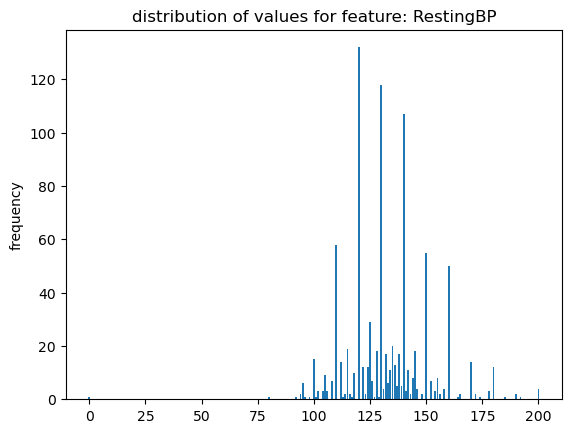

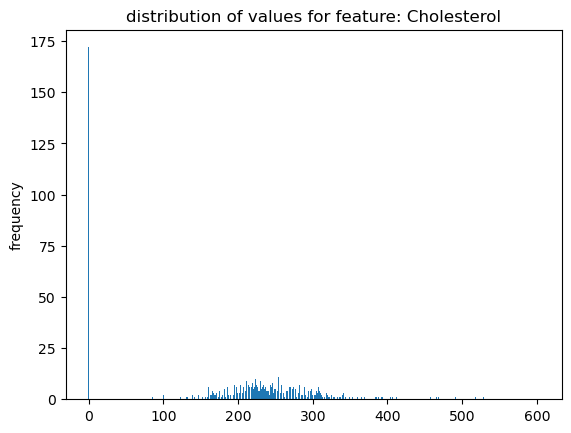

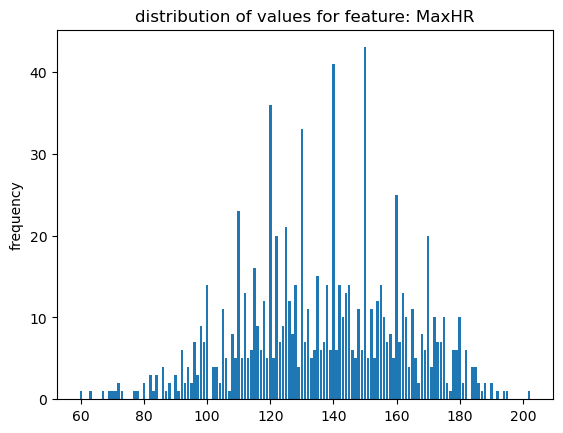

In [3]:
# ADD CODE HERE
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("heart.csv")

data.head()


def get_bins_counts(column: pd.Series):
    unique = column.unique()
    counts = [0] * len(unique)

    for idx, unique_class in enumerate(unique):
        for value in column:
            if value == unique_class:
                counts[idx] = counts[idx] + 1

    return unique, counts

def plot_dis(name, bins, counts):
    
    fig, ax = plt.subplots()
    ax.bar(bins, counts)
    ax.set_ylabel("frequency")
    ax.set_title(f"distribution of values for feature: {name}")
    plt.show()



feature_names = ["Age", "RestingBP", "Cholesterol", "MaxHR"]


def plot_features(features):
    for feature in features:
        bins, counts = get_bins_counts(data[feature])
        plot_dis(feature, bins, counts)


plot_features(feature_names)






age normal distribution
oldpeak skewed distribution

cholesterol sieht komisch aus, da im Dataset 0 als markierung für "fehlende Daten" genutzt ist


Wir sehen, dass "Oldpeak" nicht besonders normalverteilt aussieht. Dieses Feature werden wir daher nicht verwenden. Bei "Cholesterol" sehen wir, dass häufig ein Wert 0 vorkommt (vermutlich da nicht gemessen). Filtern Sie den Datensatz, so dass die Werte ohne Cholesterol rausfliegen. Plotten Sie anschließend noch einmal Histogramme für die 4 potentiellen Features.

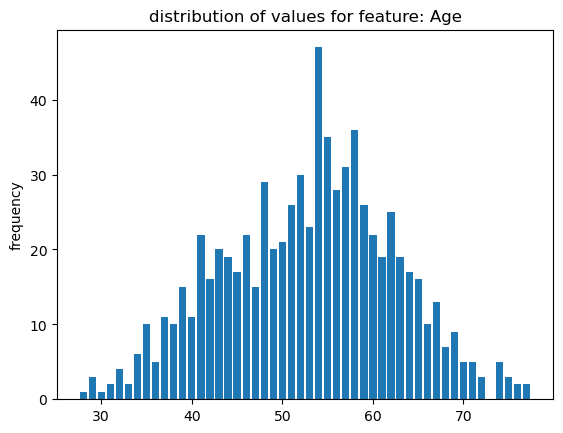

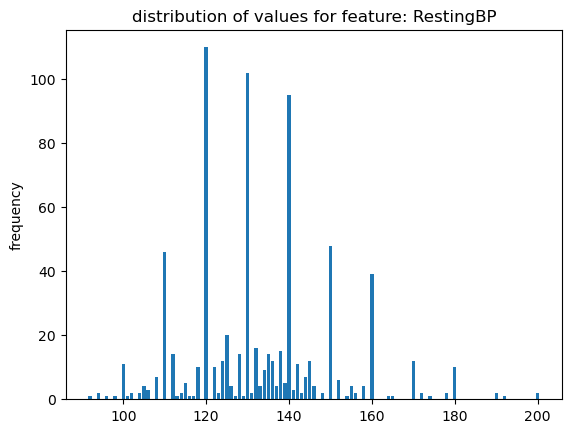

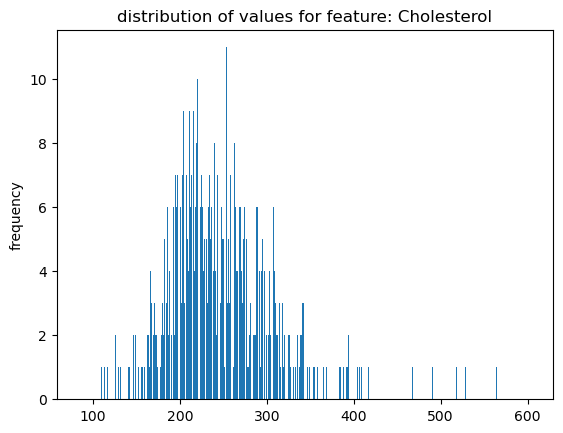

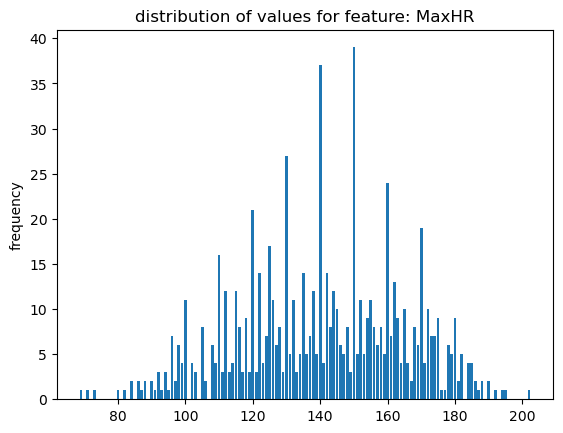

746


In [4]:
# ADD CODE HERE

data = data[
    data["Cholesterol"] != 0 #boolean mask
]

plot_features(feature_names)

print(len(data))


Fitten Sie nun eine Logistische Regression und berechne die Accuracy als Benchmark

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ADD CODE HERE

model = LogisticRegression()
features = data.drop(columns = ["HeartDisease"])
features = data[feature_names]
labels = data["HeartDisease"]
model.fit(features, labels)

pred = model.predict(features)
print(f"Train acc:\n{accuracy_score(labels, pred)}\n")

Train acc:
0.7091152815013405



Verwenden Sie als nächstes LinearDiscriminantAnalysis mit dem Parameter `solver="eigen"`. Mit dem default Solver wird nicht die Kovarianz Matrix berechnet, daher setzen wir diesen hier anders. Die Klasse LinearDiscriminantAnalysis kann mehr, als GDA berechnen, darauf gehen wir an dieser Stelle aber nicht weiter ein.

Berechnen Sie wieder die Accuracy.

In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn import metrics

# ADD CODE HERE

clf = LinearDiscriminantAnalysis(solver="eigen")
clf.fit(features, labels)

pred_clf = clf.predict(features)
print(f"Train acc:\n{accuracy_score(labels, pred_clf)}\n")


'''
Warum ist die Train Accuracy bei der Nutzung von GDA schlechter als bei der logistischen Regression?

GDA nimmt an, dass die Daten normalverteilt sind, um Gauß-Verteilungen für die Klassen zu modellieren.
Unsere Daten sind jedoch größtenteils nicht normalverteilt. Daher ist die Annahme von GDA über die Verteilung der Daten oft falsch.

Die logistische Regression modelliert dagegen nicht die Verteilung der Daten selbst, sondern lernt direkt die Entscheidungsgrenze zwischen den Klassen,
um die Wahrscheinlichkeit der jeweiligen Klasse zu berechnen.

Daraus lässt sich folgern, dass die logistische Regression für nicht normalverteilte Daten oft der bessere Klassifikator ist.
'''


Train acc:
0.707774798927614



'\nWarum ist die Train Accuracy bei der Nutzung von GDA schlechter als bei der logistischen Regression?\n\nGDA nimmt an, dass die Daten normalverteilt sind, um Gauß-Verteilungen für die Klassen zu modellieren.\nUnsere Daten sind jedoch größtenteils nicht normalverteilt. Daher ist die Annahme von GDA über die Verteilung der Daten oft falsch.\n\nDie logistische Regression modelliert dagegen nicht die Verteilung der Daten selbst, sondern lernt direkt die Entscheidungsgrenze zwischen den Klassen,\num die Wahrscheinlichkeit der jeweiligen Klasse zu berechnen.\n\nDaraus lässt sich folgern, dass die logistische Regression für nicht normalverteilte Daten oft der bessere Klassifikator ist.\n'

Mit `model.covariance_`, können wir uns die Kovarianz Matrix, mit `model.means_` die Mittelwerte je Klasse und mit `model.priors_` die Wahrscheinlichkeiten je Klasse anzeigen.

In [7]:
# ADD CODE HERE
cov_mat = clf.covariance_
print(cov_mat)

print()

means = clf.means_ 
print(means)

priors = clf.priors_


'''
Covarianz matrix:

Diagonal - Varianz der einzelnen features
alle anderen values - covarinanz (ob die features zusammenwachsen usw)

'''

[[  82.19383283   34.14771224   15.57873568  -62.73561864]
 [  34.14771224  289.3404829    79.57958493  -25.57648158]
 [  15.57873568   79.57958493 3456.75049761   27.99489991]
 [ -62.73561864  -25.57648158   27.99489991  515.16318161]]

[[ 50.17179487 130.16410256 238.76923077 149.05897436]
 [ 55.8511236  136.15449438 251.06179775 130.5505618 ]]


'\nCovarianz matrix:\n\nDiagonal - Varianz der einzelnen features\nalle anderen values - covarinanz (ob die features zusammenwachsen usw)\n\n'

Durch unser Modell haben wir nicht nur die Möglichkeit, Vorhersagen zu treffen, sondern erhalten mehr Wissen darüber, wie eigentlich porsitve und negative Beispiele aussehen. Diese Möglichkeit sorgt dafür, dass GDA Modelle einen hohen Level an Erklärbarkeit haben.

Mit `np.random.multivariate_normal` können wir uns Beispiele einer Mehrdimensionalen Normalverteilung erzeugen. Dabei müssen wir den Mean Vektor und die Kovarianzmatrix übergeben. Erzeugen Sie 10000 Beispiele für Patienten jeweils mit oder ohne Herzerkrankung.

Filtern Sie diese Beispiele dann auf die Personen ab 60 Jahre und Bilde dann den Durchschnitt über die Spalten. Damit haben wir simuliert, Beispielsweise welchen Cholesterol Level eine durchschnittliche Person ab 60 mit / ohne Herzkrankheit hat.

In [8]:
import numpy as np
# ADD CODE HERE

def get_normal_distributed_df(feature_names: list, means_vector:list, covariance_mtrx:list[list]):
    normaldistributed_data = pd.DataFrame(columns = feature_names)
    for i in range(10000):
        series = np.random.multivariate_normal(np.asanyarray(means_vector), np.asanyarray(covariance_mtrx))
        normaldistributed_data = pd.concat(
            [pd.DataFrame([series], columns = normaldistributed_data.columns), normaldistributed_data], ignore_index= True)
    return normaldistributed_data

def getMeans(feature_names, source_df):
    means = {}
    for feature in feature_names:
        means[feature] = source_df[feature].mean()

    return pd.DataFrame([means])


#HEALTHY
ten_k_pats_healthy = get_normal_distributed_df(feature_names, clf.means_[0], clf.covariance_)

pats_healthy_over_60 = ten_k_pats_healthy[
                             ten_k_pats_healthy["Age"] > 60 #boolean mask
                            ]
means_healthy = getMeans(feature_names, pats_healthy_over_60)

#SICK
ten_k_pats_sick = get_normal_distributed_df(feature_names, clf.means_[1], clf.covariance_)
pats_sick_over_60 = ten_k_pats_sick[
                             ten_k_pats_sick["Age"] > 60 #boolean mask
                            ]
means_sick = getMeans(feature_names, pats_sick_over_60)


print(f"\nProfile of healthy pat over 60 y.o: \n{means_healthy}\nProfile of sick pat over 60 y.o: \n{means_sick}")




/var/folders/zn/hcv2bckd7fq8rn89fpfskfwm0000gn/T/ipykernel_57136/1685331391.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  normaldistributed_data = pd.concat(
/var/folders/zn/hcv2bckd7fq8rn89fpfskfwm0000gn/T/ipykernel_57136/1685331391.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  normaldistributed_data = pd.concat(



Profile of healthy pat over 60 y.o: 
         Age   RestingBP  Cholesterol       MaxHR
0  64.612154  136.018256   239.414191  137.794951
Profile of sick pat over 60 y.o: 
         Age   RestingBP  Cholesterol       MaxHR
0  65.997463  140.754702   252.334154  122.763983


Auf den gewählten Features funktioniert das GDA Modell ein klein wenig besser als die Logistische Regression. Der Vorteil bei dieser ist jedoch, dass sie nicht von einer Normalverteilung der Daten ausgeht. Wir können also auch einfach die Features "Oldpeak" und "FastingBS" verwenden. Fitten Sie nun je eine Logistische Regression und eine LinearDiscriminantAnalysis mit diesen insgesamt 6 Features und vergleichen Sie die Accuracy.

In [49]:
# ADD CODE HERE
features = data[["Age","RestingBP","Cholesterol","MaxHR","Oldpeak","FastingBS"]]

labels = data["HeartDisease"]

models = {"logistische regression": LogisticRegression(),
            "linear discriminant analysis" : LinearDiscriminantAnalysis()
        }

for name, model in models.items():
    print(f"fit for model {name} has been started")
    model.fit(features, labels)
    pred = model.predict(features)
    print(f"Train acc for model {model}:\n{accuracy_score(labels, pred)}\n\n")

fit for model logistische regression has been started
Train acc for model LogisticRegression():
0.7721179624664879


fit for model linear discriminant analysis has been started
Train acc for model LinearDiscriminantAnalysis():
0.7694369973190348


